In [1]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import argparse
import numpy as np
import random
import scipy
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt
import random
from scipy.stats import kendalltau
import pandas as pd

In [2]:
edges=np.genfromtxt("./opsahl-powergrid/out.opsahl-powergrid",
                                        dtype=int)
edges=edges-1
adj = sp.coo_matrix((np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
                        shape=(4941, 4941))
adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)

adj_powergrid = torch.FloatTensor(np.array(adj.todense()))
adj=np.array(adj_powergrid)
G_powergrid = nx.Graph()
G_powergrid = nx.from_numpy_array(adj) 
list_powergrid=list(range(4941))

In [109]:
def min_max_normalization(tensor):
    # 找出数组的最小值和最大值
    min_val = torch.min(tensor)
    max_val = torch.max(tensor)

    # 进行最小 - 最大标准化
    normalized_tensor = (tensor - min_val) / (max_val - min_val)
    return normalized_tensor
# node_feature_BA = min_max_normalization(node_feature_BA)
# node_feature_BA1 = min_max_normalization(node_feature_BA1)

In [51]:
import torch

def min_max_normalize_by_col(tensor):
    # 按列计算最小/最大值
    min_vals = torch.min(tensor, dim=0, keepdim=True)[0]
    max_vals = torch.max(tensor, dim=0, keepdim=True)[0]
    
    # 计算分母
    denominator = max_vals - min_vals
    
    # 🔥 核心修复：如果分母为0（整列数值相同），赋值为1，避免除以0
    denominator[denominator == 0] = 1.0
    
    # 按列归一化
    normalized = (tensor - min_vals) / denominator
    
    # 可选：把原本全相同的列强制设为0（更规范）
    # 找到全相同的列，赋值0
    zero_mask = (max_vals == min_vals).squeeze()
    normalized[:, zero_mask] = 0.0
    
    return normalized

In [111]:
lable_powergrid=np.load("lable/test_1000times_lable_powergrid_1.5.npy")
lable_powergrid_t=torch.tensor(lable_powergrid).float()
node_feature_powergrid=torch.load("EC做损失的特征向量/node_feature_powergrid_LSTM_EC_0.005_300.pt")
# node_feature_powergrid = min_max_normalization(node_feature_powergrid)
# node_feature_powergrid = min_max_normalization(node_feature_powergrid)
node_feature_powergrid = min_max_normalize_by_col(node_feature_powergrid)


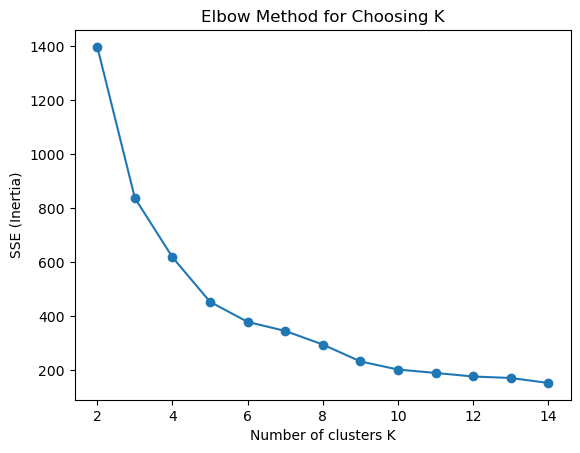

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 假设你的特征矩阵叫 node_feature_powergrid
X = node_feature_powergrid.detach().numpy()

# 1. 肘部法则（Elbow Method）
sse = []
k_list = range(2, 15)  # 尝试K从2到14
for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # inertia_就是SSE

plt.figure()
plt.plot(k_list, sse, marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Choosing K')
plt.show()

In [115]:
import numpy as np
from sklearn.cluster import KMeans
# 假设 node_feature_jazz 是你的节点特征矩阵，形状是 (num_nodes, feature_dim)
random.seed(17)
np.random.seed(17)
torch.manual_seed(17)
    
# 设置聚类数量
k = 5
X = node_feature_powergrid.detach().numpy()

# 执行 KMeans 聚类
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

# labels 是每个节点对应的聚类类别，比如 labels[i] 是第i个节点所属的簇编号

# 将节点按簇分类整理
cluster_nodes = {i: [] for i in range(k)}
for idx, label in enumerate(labels):
    cluster_nodes[label].append(idx)
#选择训练集的节点
n_nodes = node_feature_powergrid.shape[0]

# 1. 随机采样 5% 的节点索引
num_train = int(0.1 * n_nodes)
split_idx=int(num_train * 0.5)+1
sum_idx = []
while len(sum_idx) < num_train:
    for i in range(k):
        if cluster_nodes[i]:  # 确保当前簇中还有节点可取
            node = random.choice(cluster_nodes[i])  # 随机选一个
            sum_idx.append(node)
            cluster_nodes[i].remove(node)
            if len(sum_idx) >= num_train:
                break
print(sum_idx)
train_idx=sum_idx[:split_idx]
pinggu_idx=sum_idx[split_idx:]
print(train_idx)
print(pinggu_idx)
# 2. 构造训练集（只选取部分节点特征）
train_powergrid = node_feature_powergrid[train_idx]
train_powergrid_lable = lable_powergrid_t[train_idx]
# 3. 测试集就是整个 node_feature_BA
pinggu_powergrid = node_feature_powergrid
pinggu_powergrid_lable = lable_powergrid_t[pinggu_idx]
sum_powergrid_lable=lable_powergrid_t[sum_idx]

[4389, 3167, 1771, 2343, 2512, 1786, 4164, 4674, 2063, 680, 264, 1874, 2494, 2977, 1666, 4346, 2442, 4544, 4852, 2875, 1037, 4314, 392, 1455, 1257, 1325, 4123, 3895, 4870, 1323, 3215, 4201, 751, 4690, 432, 3125, 3110, 511, 3771, 3490, 1130, 3105, 3431, 2235, 103, 3837, 2847, 3981, 481, 2761, 461, 3693, 2411, 4147, 21, 3705, 1830, 717, 4046, 1391, 2708, 4095, 2323, 523, 2376, 600, 2110, 1172, 4569, 4428, 4507, 4459, 828, 2009, 2593, 3293, 2452, 1063, 2232, 615, 4842, 4688, 1632, 2269, 51, 462, 2683, 142, 3617, 2519, 4265, 430, 1222, 2150, 2344, 696, 3803, 149, 4630, 4444, 4485, 1179, 2647, 3709, 4666, 3632, 1507, 1199, 2011, 1176, 852, 1703, 328, 3979, 2608, 3165, 2450, 325, 1605, 3159, 777, 2433, 1524, 4818, 3086, 4308, 612, 3834, 1016, 4433, 2648, 1765, 3645, 2036, 4530, 1672, 2294, 322, 3735, 3033, 4333, 1754, 3923, 2980, 4416, 4057, 627, 3089, 1928, 1531, 4325, 2473, 1161, 2397, 198, 4901, 4645, 3552, 3158, 369, 3238, 4760, 1067, 4120, 1838, 3162, 2861, 1079, 1912, 2644, 3943, 2802,

In [117]:
class GNN(torch.nn.Module):
    def __init__(self,input_feature,output_feature):
        super(GNN,self).__init__()
        self.w = nn.Parameter(torch.empty(size=(input_feature,output_feature)))
        self.a= nn.Parameter(torch.empty(size=(1,output_feature)))
        self.sigmod=torch.nn.Sigmoid()
        self.reset_parameters()
    def reset_parameters(self):
        #nn.init.xavier_uniform_(self.w.data,gain=1.414)
        #nn.init.xavier_uniform_(self.a.data,gain=1.414)
        for param in self.parameters():
             nn.init.xavier_uniform_(param)
        
    def forward(self,x,adj):
        adj=torch.Tensor(adj.numpy()+np.identity(adj.shape[0]))
        # adj=torch.FloatTensor(normalize_adj(sp.csr_matrix(adj)+ sp.eye(adj.shape[0])).todense())
        x=torch.mm(adj,x)
        x=torch.mm(x,self.w)
        x=x.add(self.a)
        x=torch.relu(x)
        return x


class CGNN(torch.nn.Module):
    def __init__(self):
        super(CGNN,self).__init__()
        self.layer2=GNN(48,6)
        self.layer3=GNN(6,12)
        # self.fc1=torch.nn.Linear(6,12)
        self.fc1=torch.nn.Linear(12,1)
        # self.fc2=torch.nn.Linear(24,1)
        
        
       
     
    
    
    def forward(self,x,adj,target_nodes):
        #x=self.layer1(x)
        # x=torch.cat([x1,x],dim=-1)
        # x=0.5*x+0.5*x1
        x=self.layer2(x,adj)
        x=self.layer3(x,adj)
       # x=self.layer4(x,adj)
        
        x=x[target_nodes]
        
        x=self.fc1(x.view(x.size(0),-1))
        x=torch.relu(x)
        # x=self.fc2(x)
        # x=torch.relu(x)
        x=x.flatten()
        
        return x

In [15]:
import optuna
import time
import numpy as np
import torch
import torch.optim as optim
from scipy.stats import kendalltau

# 假设你的模型和数据已定义
# from your_model import CGNN  # 导入你的CGNN模型
# 假设以下变量已提前定义：
# node_feature_powergrid, adj_powergrid, train_idx, list_powergrid, list_pinggu
# train_powergrid_lable, pinggu_true  # 训练标签和验证集真实值

def objective(trial):
    # 1. 定义超参数搜索空间
    learning_rate = trial.suggest_float(
        "learning_rate", 
        low=0.001, 
        high=0.01, 
        step=0.001  # 学习率：0.001-0.01，步长0.001
    )
    epochs = trial.suggest_int(
        "epochs", 
        low=100, 
        high=1000, # 训练次数：100-1000之间的任意整数
        step=100
    )

    epoch_1=trial.suggest_int(
        "epoch_1", 
        low=100, 
        high=500, # 训练次数：100-1000之间的任意整数
        step=100
    )
    learning_rate1 = trial.suggest_categorical(
        "learning_rate1", 
        [0.005,0.01,0.001]  # 仅允许这三个候选值
    )
    # 2. 初始化模型和优化器

    lable_powergrid=np.load("lable/lable_powergrid.npy")
    lable_powergrid_t=torch.tensor(lable_powergrid).float()
    node_feature_powergrid=torch.load("EC做损失的特征向量/node_feature_powergrid_LSTM_EC_"+str(learning_rate1)+"_"+str(epoch_1)+".pt")
    node_feature_powergrid = min_max_normalization(node_feature_powergrid)
    
    random.seed(17)
    np.random.seed(17)
    torch.manual_seed(17)
    
# 设置聚类数量
    k = 5
    X = node_feature_powergrid.detach().numpy()

# 执行 KMeans 聚类
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

# labels 是每个节点对应的聚类类别，比如 labels[i] 是第i个节点所属的簇编号

# 将节点按簇分类整理
    cluster_nodes = {i: [] for i in range(k)}
    for idx, label in enumerate(labels):
        cluster_nodes[label].append(idx)
#选择训练集的节点
    n_nodes = node_feature_powergrid.shape[0]

# 1. 随机采样 5% 的节点索引
    # 1. 随机采样 5% 的节点索引
    num_train = int(0.05 * n_nodes)+1

    train_idx=[]
    while len(train_idx) < num_train:
        for i in range(k):
            if cluster_nodes[i]:  # 确保当前簇中还有节点可取
                node = random.choice(cluster_nodes[i])  # 随机选一个
                train_idx.append(node)
                cluster_nodes[i].remove(node)
                if len(train_idx) >= num_train:
                    break

    pinggu_idx=[]
    while len(pinggu_idx) < num_train:
        for i in range(k):
            if cluster_nodes[i]:  # 确保当前簇中还有节点可取
                node = random.choice(cluster_nodes[i])  # 随机选一个
                pinggu_idx.append(node)
                cluster_nodes[i].remove(node)
                if len(pinggu_idx) >= num_train:
                    break

# 2. 构造训练集（只选取部分节点特征）
    train_powergrid = node_feature_powergrid[train_idx]
    train_powergrid_lable = lable_powergrid_t[train_idx]
# 3. 测试集就是整个 node_feature_BA
    
    pinggu_powergrid = node_feature_powergrid[pinggu_idx]
    pinggu_powergrid_lable = lable_powergrid_t[pinggu_idx]


    
    # 2. 初始化模型和优化器
    random.seed(17)
    np.random.seed(17)
    torch.manual_seed(17)
    model = CGNN()  # 实例化你的模型
    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=5e-4  # 保持权重衰减不变
    )
    
    # 3. 训练模型
    for epoch in range(epochs):
        # 训练过程（复用你的train函数逻辑）
        model.train()
        output = model(node_feature_powergrid.data, adj_powergrid, train_idx)
        loss_train = torch.nn.functional.mse_loss(output, train_powergrid_lable)
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        
        # 每100轮打印一次中间结果（可选）
        if (epoch + 1) % 100 == 0:
            print(f"当前参数组合: 学习率={learning_rate}, 训练次数={epochs}, 轮次={epoch+1}, 训练损失={loss_train.item():.4f}")
    
    # 4. 在验证集上评估RMSE
    model.eval()
    with torch.no_grad():  # 关闭梯度计算，节省内存
        pinggu_pre = model(node_feature_powergrid.data, adj_powergrid, pinggu_idx)
        # 转换为numpy数组计算RMSE
        pinggu_pre_np = pinggu_pre.detach().numpy()
        pinggu_true=pinggu_powergrid_lable.detach().numpy()
        # print(kendalltau(pinggu_pre_np,pinggu_pre_np))
        rmse=kendalltau(pinggu_pre_np,pinggu_true).statistic
        # rmse = np.sqrt(np.mean((pinggu_true - pinggu_pre_np) **2))
    
    # 5. 返回需要最小化的RMSE（Optuna会寻找最小RMSE对应的参数）
    return rmse

if __name__ == '__main__':
    # 创建优化实例，方向为"最小化"RMSE
    study = optuna.create_study(direction="maximize")
    # 尝试20组参数组合
    study.optimize(objective, n_trials=80)
    
    # 输出最优结果
    print("\n优化完成！")
    print(f"最佳参数组合: {study.best_params}")
    print(f"最小RMSE: {study.best_value:.4f}")
    print(f"最佳试验编号: {study.best_trial.number}")

[I 2025-12-25 17:28:49,005] A new study created in memory with name: no-name-11ec8afe-5547-4e75-8b37-599fab662ff9


当前参数组合: 学习率=0.004, 训练次数=900, 轮次=100, 训练损失=20793.7227
当前参数组合: 学习率=0.004, 训练次数=900, 轮次=200, 训练损失=18551.6035
当前参数组合: 学习率=0.004, 训练次数=900, 轮次=300, 训练损失=17042.2559
当前参数组合: 学习率=0.004, 训练次数=900, 轮次=400, 训练损失=15950.3379
当前参数组合: 学习率=0.004, 训练次数=900, 轮次=500, 训练损失=15115.3447
当前参数组合: 学习率=0.004, 训练次数=900, 轮次=600, 训练损失=14441.5186
当前参数组合: 学习率=0.004, 训练次数=900, 轮次=700, 训练损失=13871.9033
当前参数组合: 学习率=0.004, 训练次数=900, 轮次=800, 训练损失=13374.1797


[I 2025-12-25 17:32:11,032] Trial 0 finished with value: 0.5258586913934962 and parameters: {'learning_rate': 0.004, 'epochs': 900, 'epoch_1': 500, 'learning_rate1': 0.01}. Best is trial 0 with value: 0.5258586913934962.


当前参数组合: 学习率=0.004, 训练次数=900, 轮次=900, 训练损失=12929.8467
当前参数组合: 学习率=0.008, 训练次数=200, 轮次=100, 训练损失=9938.5674
当前参数组合: 学习率=0.008, 训练次数=200, 轮次=200, 训练损失=8931.8027


[I 2025-12-25 17:32:55,466] Trial 1 finished with value: 0.5008897233546414 and parameters: {'learning_rate': 0.008, 'epochs': 200, 'epoch_1': 200, 'learning_rate1': 0.005}. Best is trial 0 with value: 0.5258586913934962.


...

当前参数组合: 学习率=0.001, 训练次数=500, 轮次=500, 训练损失=17586.6016


[W 2025-12-25 18:40:04,657] Trial 36 failed with value nan.


当前参数组合: 学习率=0.001, 训练次数=500, 轮次=100, 训练损失=17586.6016


[W 2025-12-25 18:40:34,936] Trial 37 failed with parameters: {'learning_rate': 0.001, 'epochs': 500, 'epoch_1': 100, 'learning_rate1': 0.001} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\Administrator\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Administrator\AppData\Local\Temp\ipykernel_15728\2987378785.py", line 116, in objective
    output = model(node_feature_powergrid.data, adj_powergrid, train_idx)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Administrator\anaconda3\Lib\site-packages\torch\nn\modules\module.py", line 1532, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Administrator\anaconda3\Lib\site-packages\torch\nn\modules\module.py", line 1541, in _call_impl
    return forwa

KeyboardInterrupt: 

In [123]:
node_feature_powergrid=torch.load("EC做损失的特征向量/node_feature_powergrid_LSTM_EC_0.005_100.pt")
node_feature_powergrid = min_max_normalization(node_feature_powergrid)
lable_powergrid=np.load("lable/test_1000times_lable_powergrid_1.5.npy")
lable_powergrid_t=torch.tensor(lable_powergrid).float()

In [125]:
import numpy as np
from sklearn.cluster import KMeans
# 假设 node_feature_powergrid 是你的节点特征矩阵，形状是 (num_nodes, feature_dim)
random.seed(17)
np.random.seed(17)
torch.manual_seed(17)
    
# 设置聚类数量
k = 5
X = node_feature_powergrid.detach().numpy()

# 执行 KMeans 聚类
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

# labels 是每个节点对应的聚类类别，比如 labels[i] 是第i个节点所属的簇编号

# 将节点按簇分类整理
cluster_nodes = {i: [] for i in range(k)}
for idx, label in enumerate(labels):
    cluster_nodes[label].append(idx)
#选择训练集的节点
n_nodes = node_feature_powergrid.shape[0]

# 1. 随机采样 5% 的节点索引
num_train = int(0.05 * n_nodes)+1

train_idx=[]
while len(train_idx) < num_train:
    for i in range(k):
        if cluster_nodes[i]:  # 确保当前簇中还有节点可取
            node = random.choice(cluster_nodes[i])  # 随机选一个
            train_idx.append(node)
            cluster_nodes[i].remove(node)
            if len(train_idx) >= num_train:
                break

pinggu_idx=[]
while len(pinggu_idx) < num_train:
    for i in range(k):
        if cluster_nodes[i]:  # 确保当前簇中还有节点可取
            node = random.choice(cluster_nodes[i])  # 随机选一个
            pinggu_idx.append(node)
            cluster_nodes[i].remove(node)
            if len(pinggu_idx) >= num_train:
                break

# 2. 构造训练集（只选取部分节点特征）
train_powergrid = node_feature_powergrid[train_idx]
train_powergrid_lable = lable_powergrid_t[train_idx]
# 3. 测试集就是整个 node_feature_BA
    
pinggu_powergrid = node_feature_powergrid[pinggu_idx]
pinggu_powergrid_lable = lable_powergrid_t[pinggu_idx]

In [127]:
import time
import numpy as np
import torch
import torch.optim as optim
from scipy.stats import kendalltau

# 确保随机种子完全一致
random.seed(17)
np.random.seed(17)
torch.manual_seed(17)
# 对于CUDA环境，还需固定cuda随机种子
if torch.cuda.is_available():
    torch.cuda.manual_seed(17)
    torch.cuda.manual_seed_all(17)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train(epoch, model, optimizer, node_feature, adj, train_idx, train_label):
    model.train()
    output = model(node_feature.data, adj, train_idx)
    loss = torch.nn.functional.mse_loss(output, train_label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

if __name__ == '__main__':
    # 确保数据与Optuna调优时完全一致
    # （需与objective函数中使用的node_feature_powergrid、adj_powergrid等保持相同）
    # 假设以下变量已正确定义：
    # node_feature_powergrid, adj_powergrid, train_idx, train_powergrid_lable, sum_idx, sum_powergrid_lable
    
    # 初始化模型和优化器（与Optuna中完全一致）
    model = CGNN()  # 重新初始化，确保权重初始状态一致
    optimizer = optim.Adam(
        model.parameters(),
        lr=0.01,  # Optuna找到的最佳学习率
        weight_decay=5e-4
    )
    
    # 记录总训练时间
    t_total = time.time()
    loss_values = []
    
    # 训练600轮（与Optuna最佳参数一致）
    for epoch in range(800):
        loss = train(epoch, model, optimizer, node_feature_powergrid, adj_powergrid, train_idx, train_powergrid_lable)
        loss_values.append(loss)
        
        # 每100轮打印训练损失（与Optuna中保持一致的监控频率）
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}, 训练损失: {loss:.4f}")
    
    # 关键：添加与Optuna中完全一致的评估步骤
    model.eval()
    with torch.no_grad():
        # 使用相同的评估索引和标签
        pinggu_pre = model(node_feature_powergrid.data, adj_powergrid, pinggu_idx)
        pinggu_pre_np = pinggu_pre.detach().numpy()
        pinggu_true = pinggu_powergrid_lable.detach().numpy()
        # 计算Kendall系数（与Optuna中评估指标一致）
        kendall = kendalltau(pinggu_pre_np, pinggu_true).statistic
        print(f"最终Kendall系数: {kendall:.6f}")
    
    print("Optimization Finished!")
    print(f"Total time elapsed: {time.time() - t_total:.2f}s")

Epoch 100, 训练损失: 4499.8506
Epoch 200, 训练损失: 3661.8005
Epoch 300, 训练损失: 3303.8406
Epoch 400, 训练损失: 3132.4753
Epoch 500, 训练损失: 3010.6851
Epoch 600, 训练损失: 2712.3252
Epoch 700, 训练损失: 2488.1516
Epoch 800, 训练损失: 2302.8757
最终Kendall系数: 0.628249
Optimization Finished!
Total time elapsed: 310.49s


In [135]:
pinggu_pre = model(node_feature_powergrid.data, adj_powergrid, pinggu_idx)
# 转换为numpy数组计算RMSE
pinggu_pre_np = pinggu_pre.detach().numpy()
pinggu_true=pinggu_powergrid_lable.detach().numpy()
# print(kendalltau(pinggu_pre_np,pinggu_pre_np))
rmse=kendalltau(pinggu_pre_np,pinggu_true).statistic
print(rmse)

0.6282486613556223


In [153]:
lable_powergrid=np.load("lable/test_1000times_lable_powergrid_1.5.npy")
lable_powergrid_t=torch.tensor(lable_powergrid).float()

In [155]:
model_cgnn=model
model_cgnn.eval()
start=time.time()
output = model_cgnn(node_feature_powergrid.data,adj_powergrid,list_powergrid)
# print(output)

# temp=list(set(list_powergrid)-set(train_idx+pinggu_idx))
# output_temp=output[temp]
# lable_powergrid_t_temp=lable_powergrid_t[temp]
# print(kendalltau(output_temp.detach().numpy(),lable_powergrid_t_temp))

print(kendalltau(output.detach().numpy(),lable_powergrid_t))




# output_rank=output.detach().numpy().argsort()

# # print(output_rank)
# # print(label_rank)
# loss_train = torch.nn.functional.mse_loss(output,lable_powergrid_t)
# # print(loss_train)
# print(kendalltau(output.detach().numpy(),lable_powergrid_t))
# # print(MI(output))


SignificanceResult(statistic=0.5578693573253368, pvalue=0.0)


In [29]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np

def calculate_node_ranking(node_scores):
    # 1. 处理纯得分列表（自动生成节点ID，如node_0, node_1...）
    if isinstance(node_scores, list) and all(isinstance(x, (int, float)) for x in node_scores):
        df = pd.DataFrame({
            'node': [f'node_{i}' for i in range(len(node_scores))],
            'score': node_scores
        })

    # 2. 按得分降序排序（影响力越高，得分越高，排名越靠前）
    df_sorted = df.sort_values(by='score', ascending=False).reset_index(drop=True)

    # 3. 计算稠密排名（同得分同排名）
    df_sorted['rank'] = df_sorted['score'].rank(method='dense', ascending=False).astype(int)

    return df_sorted

def calculate_ccdf_full_and_sample(df_ranked, N_total, step=40):

    # ========== 第一步：补全1~N_total所有位次的CCDF值 ==========
    # 1. 统计每个实际排名的节点数和累计数
    rank_count = df_ranked.groupby('rank')['node'].count().reset_index(name='n_i')
    rank_count['sum_n_i'] = rank_count['n_i'].cumsum()
    rank_count['ccdf'] = 1 - rank_count['sum_n_i'] / N_total

    # 2. 构建1~N_total的完整位次映射
    full_rank_list = list(range(1, N_total + 1))  # 1到网络总节点数的所有位次
    full_ccdf_list = []
    current_ccdf = 1.0  # 初始值
    rank_to_ccdf = dict(zip(rank_count['rank'], rank_count['ccdf']))

    # 补全每个位次的CCDF值（缺失位次继承前值）
    for r in full_rank_list:
        if r in rank_to_ccdf:
            current_ccdf = rank_to_ccdf[r]
        full_ccdf_list.append(current_ccdf)

    # 构建完整位次的DataFrame
    full_ccdf_df = pd.DataFrame({
        'rank': full_rank_list,  # 1~N_total的所有位次
        'ccdf': full_ccdf_list
    })

    # ========== 第二步：按步长抽取（基于完整位次） ==========
    total_full_ranks = len(full_ccdf_df)  # 等于N_total
    # 生成基础采样索引（步长为step）
    sample_indices = list(range(0, total_full_ranks, step))
    # 补充最后一个位次的索引
    last_index = total_full_ranks - 1
    if last_index not in sample_indices:
        sample_indices.append(last_index)
    # 去重+排序
    sample_indices = sorted(list(set(sample_indices)))

    # 按索引抽取数据
    sampled_ccdf_df = full_ccdf_df.iloc[sample_indices].reset_index(drop=True)
    sampled_ccdf_values = sampled_ccdf_df['ccdf'].tolist()
    sampled_ranks = sampled_ccdf_df['rank'].tolist()

    return full_ccdf_df, sampled_ccdf_df, sampled_ccdf_values, sampled_ranks

In [31]:
output=output.detach().numpy().tolist()
N_total = len(output)
print(N_total)
    # 步骤1：计算节点排名
df_ranked = calculate_node_ranking(output)
# print(df_ranked)
# total_ranks_actual = len(df_ranked.groupby('rank'))
total_ranks_actual= N_total
print(f"实际总排名数：{total_ranks_actual}")

# 步骤2：按步长40抽取CCDF（自动补充最后一个）
full_ccdf_df, sampled_ccdf_df, sampled_ccdf_values, sampled_ranks = calculate_ccdf_full_and_sample(df_ranked, N_total, step=1)

# 输出结果
# print("\n=== 抽取的位次（1~1200）===")


# for rank in sampled_ranks:
#     print(rank)

print(f"\n=== 最终抽取的CCDF值（共{len(sampled_ccdf_values)}个）===")
for value in sampled_ccdf_values:
    print(round(value, 4))  # 保留4位小数，更整洁
# print(sampled_ccdf_values)

4941
实际总排名数：4941

=== 最终抽取的CCDF值（共4941个）===
0.9998
0.9996
0.9994
0.9992
0.999
0.9988
0.9986
0.9984
0.9982
0.998
0.9978
0.9976
0.9974
0.9972
0.997
0.9968
0.9966
0.9964
0.9962
0.996
0.9957
0.9955
0.9953
0.9951
0.9949
0.9947
0.9945
0.9943
0.9941
0.9939
0.9937
0.9935
0.9933
0.9931
0.9929
0.9927
0.9925
0.9923
0.9921
0.9919
0.9917
0.9915
0.9913
0.9911
0.9909
0.9907
0.9905
0.9903
0.9901
0.9899
0.9897
0.9895
0.9893
0.9891
0.9889
0.9887
0.9885
0.9883
0.9881
0.9879
0.9877
0.9875
0.9872
0.987
0.9868
0.9866
0.9864
0.9862
0.986
0.9858
0.9856
0.9854
0.9852
0.985
0.9848
0.9846
0.9844
0.9842
0.984
0.9838
0.9836
0.9834
0.9832
0.983
0.9828
0.9826
0.9824
0.9822
0.982
0.9818
0.9816
0.9814
0.9812
0.981
0.9808
0.9806
0.9804
0.9802
0.98
0.9798
0.9796
0.9794
0.9792
0.979
0.9787
0.9785
0.9783
0.9781
0.9779
0.9777
0.9775
0.9771
0.9769
0.9767
0.9765
0.9763
0.9761
0.9759
0.9757
0.9755
0.9753
0.9751
0.9749
0.9747
0.9745
0.9743
0.9741
0.9739
0.9737
0.9735
0.9733
0.9731
0.9729
0.9727
0.9725
0.9723
0.9721
0.9719
0.97

In [25]:

# end=time.time()
# print(end-start)
output_rank=output.detach().numpy().argsort()

# print(output_rank)
# print(label_rank)
loss_train = torch.nn.functional.mse_loss(output,lable_powergrid_t)
# print(loss_train)
print(kendalltau(output.detach().numpy(),lable_powergrid_t))
print(MI(output))


NameError: name 'output' is not defined

In [126]:
def MI(res):
    a=pd.DataFrame(res.detach().numpy())
    x=len(a)
    a.rank(axis=0,method='min',numeric_only=None,
    na_option='keep',ascending=True,pct=False)
    b=a.iloc[:,0].value_counts()
    y=0
    for i in range(len(b)):
        y=y+b.iloc[i]*(b.iloc[i]-1)
    ans=(1-y/(x*(x-1)))*(1-y/(x*(x-1)))
    return ans

In [122]:
def calculate_top_k_jaccard(list1, list2,length):
    """
    计算两个列表按影响力排序后不同Top-K集合的Jaccard相似度
    
    参数:
    list1, list2: 节点影响力列表，下标为节点ID，值为影响力
    k_list: 需要计算的K值列表，默认为[100, 200, 300]
    
    返回:
    字典，键为K，值为对应Jaccard相似度
    """
    # 将列表转换为NumPy数组
    k_list = [int(length*0.05),int(length*0.06),int(length*0.07),int(length*0.08),int(length*0.09),int(length*0.10),int(length*0.11),int(length*0.12),int(length*0.13),int(length*0.14),int(length*0.15),int(length*0.16),int(length*0.17),int(length*0.18),int(length*0.19),int(length*0.20),int(length*0.21),int(length*0.22),int(length*0.23),int(length*0.24),int(length*0.25),int(length*0.26),int(length*0.27),int(length*0.28),int(length*0.29),int(length*0.30),int(length*0.31),int(length*0.32),int(length*0.33),int(length*0.34),int(length*0.35),int(length*0.36),int(length*0.37),int(length*0.38),int(length*0.39),int(length*0.40),int(length*0.41),int(length*0.42),int(length*0.43),int(length*0.44),int(length*0.45),int(length*0.46),int(length*0.47),int(length*0.48),int(length*0.49),int(length*0.50)]
    array1 = np.array(list1)
    array2 = np.array(list2)
    
    # 对数组排序并获取节点ID（argsort默认升序，加负号转为降序）
    sorted_indices1 = np.argsort(-array1)  # array1中影响力从大到小的节点ID
    # print(sorted_indices1)
    sorted_indices2 = np.argsort(-array2)  # array2中影响力从大到小的节点ID
    # print(sorted_indices2)
    # 计算各Top-K的Jaccard相似度
    results = {}
    for k in k_list:
        # 取前k个节点ID形成集合
        top_k_set1 = set(sorted_indices1[:k])
        top_k_set2 = set(sorted_indices2[:k])
        
        # 计算交集和并集大小
        intersection = len(top_k_set1 & top_k_set2)
        union = len(top_k_set1 | top_k_set2)
        
        # 计算Jaccard相似度
        jaccard = intersection / union if union > 0 else 0
        results[k] = jaccard
    
    return results

In [124]:
length=len(output)
k_list = [int(length*0.05),int(length*0.1),int(length*0.15),int(length*0.2),int(length*0.25),int(length*0.3),int(length*0.35),int(length*0.4),int(length*0.45),int(length*0.5)]
similarities = calculate_top_k_jaccard(output.detach().numpy(), lable_powergrid_t,length)
for k, sim in similarities.items():
    print(sim)

0.4402332361516035
0.4474327628361858
0.4587737843551797
0.46296296296296297
0.4899328859060403
0.49019607843137253
0.49586776859504134
0.47080745341614905
0.4724770642201835
0.48283261802575106
0.47904191616766467
0.4752567693744164
0.477112676056338
0.47674418604651164
0.46906812842599843
0.47242921013412814
0.47301136363636365
0.47589952477936187
0.4849673202614379
0.49056603773584906
0.4897466827503016
0.4904236796285548
0.5022522522522522
0.5081788440567067
0.5169491525423728
0.5231243576567317
0.5325325325325325
0.5349514563106796
0.5406427221172023
0.5453290381960424
0.5562556255625563
0.5610184372256365
0.5684255684255685
0.5746644295302014
0.5806319244973328
0.5839679358717434
0.595116187475384
0.6054158607350096
0.6109215017064846
0.6157562244518766
0.6214442013129103
0.6245977833392921
0.6271899088997898
0.6278750429110882
0.6325016857720837
0.6357615894039735


In [ ]:
#最好的是0.005/100 0.01/800次   然后把评估集和验证集的真实值赋予对应节点的值

In [ ]:
# 1.0β  #0.005/100，训练1000次/0.01，0.74608739，5个聚簇。
0.7460873983975412
0.7210146023313216
0.6865051745721258
0.6372117335164111
0.5925454972030944
0.5537287393452441
0.5246052571354058
0.5117296642756772
0.5231081078286309
0.5443775699895467
0.568854624957276